<a href="https://colab.research.google.com/github/Raskovm/Busqueda-para-Satisfaccion-de-Restricciones/blob/main/OS_B%C3%BAsqueda_para_Satisfacci%C3%B3n_de_Restricciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Coloreando Europa Central

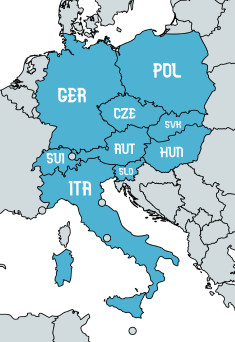

## Representación

In [ ]:
import copy

### Variables, dominio y restricciones

En la siguiente celda se listan las iniciales de todas las regiones que aparecen en el mapa. También se se crea un *set* con los colores que se utilizarán para colorear el mapa. De una manera general estamos definiendo cuáles son las variables del problema y su dominio de definición.

In [ ]:
name_regions = ["GER","POL","CZE","SVK","SUI","AUT","HUN","ITA","SLO"]
all_colors   = {"Red","Green","Blue","Yellow"}

Ahora, es necesario conocer cuáles serán las restricciónes del problema. En el caso de este problema, la restricción consiste en que dos regiones vecinas NO deberán estar pintadas del mismo color. Para formular estas restricciones es necesario conocer las parejas de vecinos existentes.

In [ ]:
neighboring_regions = [ ("GER", "POL"),
                        ("GER", "CZE"),
                        ("GER", "SUI"),
                        ("GER", "AUT"),
                        ("POL", "CZE"),
                        ("POL", "SVK"),
                        ("CZE", "SVK"),
                        ("CZE", "AUT"),
                        ("SVK", "AUT"),
                        ("SVK", "HUN"),
                        ("SUI", "AUT"),
                        ("SUI", "ITA"),
                        ("AUT", "HUN"),
                        ("AUT", "ITA"),
                        ("AUT", "SLO"),
                        ("HUN", "SLO"),
                        ("ITA", "SLO") ]

### Creación de la gráfica

Ahora que tenemos las relaciones de vecindad presentes en el mapa podemos crear una gráfica que las represente. Para cada región se podrán consultar cuáles son sus regiones vecinas. Nótese que la representación utilizada no es única; se podrían utilizar matrices booleanas, por mencionar otra alternativa.

In [ ]:
graph = dict()

# Para cada region crear un 'set' que contendrá a sus vecinos
for region_name in name_regions:
    graph[region_name] = set()

# Con cada relación de vecinos:
#    hacer explícito en el set de cada miembro, que el otro es su vecino.
for region_x,region_y in neighboring_regions:
    graph[region_x].add(region_y)
    graph[region_y].add(region_x)

# Impresión de la gráfica
for name,neighbors in graph.items():
    print( "{:3s} tiene como vecinos a: {}".format(name,neighbors) )

GER tiene como vecinos a: {'SUI', 'POL', 'CZE', 'AUT'}
POL tiene como vecinos a: {'CZE', 'SVK', 'GER'}
CZE tiene como vecinos a: {'POL', 'AUT', 'SVK', 'GER'}
SVK tiene como vecinos a: {'HUN', 'POL', 'CZE', 'AUT'}
SUI tiene como vecinos a: {'AUT', 'ITA', 'GER'}
AUT tiene como vecinos a: {'ITA', 'SLO', 'HUN', 'SVK', 'SUI', 'CZE', 'GER'}
HUN tiene como vecinos a: {'SLO', 'AUT', 'SVK'}
ITA tiene como vecinos a: {'SLO', 'SUI', 'AUT'}
SLO tiene como vecinos a: {'HUN', 'AUT', 'ITA'}


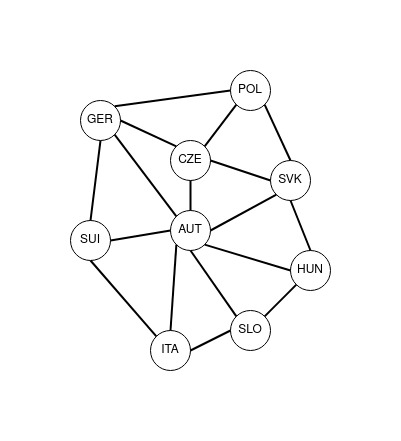

### Representando una región del mapa

Colorear el mapa podemos pensarlo como reducir sucesivamente el dominio de las variable del problema. Por ejemplo, para la variable ***\"AUT\"***, al fijar un color reducimos su dominio a ***\{"Blue"\}***. Esto afectará a sus vecinos, reduciendo el dominio de los mismos para que se mantenga la consistencia. Por ello, es necesario que representemos a las regiones en una estructura que nos permita manipularlas de una manera más sencilla. Así que proponemos el uso de la clase ***Region***, la cual nos describe a una región mediante su nombre, si es que ya ha sido coloreada, cuáles son los colores que pueden ser usados aún para pintar esa región y cuántos de sus vecinos no  han sido coloreados.

In [ ]:
class Region:

    def __init__(self,name,available_colors,unpainted_degree):
        self.name             = name
        self.status           = "No coloreado"
        self.available_colors = copy.deepcopy(available_colors)
        self.unpainted_degree = unpainted_degree


    # Compara las regiones, regresando cuál es más "deseable"
    def __lt__(self,other):

        # CRITERIO 1: Menor cantidad de colores disponibles
        if( len(self.available_colors) == len(other.available_colors) ):

            # CRITERIO 2: Mayor cantidad de vecinos "NO COLOREADOS"
            if( self.unpainted_degree == other.unpainted_degree ):

                # CRITERIO 3: Orden alfabético
                return self.name < other.name

            return self.unpainted_degree > other.unpainted_degree

        return len(self.available_colors) < len(other.available_colors)


    def print(self):
        print( "Nombre: {}".format(self.name) )
        print( "Estado actual: {}".format(self.status) )
        print( "Colores disponibles: {}".format(self.available_colors) )
        print( "Regiones vecinas sin colorear: {}".format(self.unpainted_degree) )

Un ejemplo para el uso de esta clase, es el siguiente:

In [ ]:
poland = Region(name_regions[1], all_colors, len(graph[name_regions[1]]) )

Hacemos notar de manera explícita que: si creamos todos los objetos de la clase ***Region*** necesarios para resolver este problema sin haber coloreado ninguna región, la cantidad de regiones vecinas que no han sido coloreadas es igual a la cantidad de regiones vecinas existentes.

In [ ]:
poland.print()

Nombre: POL
Estado actual: No coloreado
Colores disponibles: {'Red', 'Blue', 'Green', 'Yellow'}
Regiones vecinas sin colorear: 3


Nótese que las regiones vecinas que no se han coloreado son: *GER*, *CZE* y *SVK*.

### Estado inicial

Ahora que tenemos la definición de los objetos ***Region*** podemos definir una función que, dada la lista de las regiones, cuáles son los colores existentes y la gráfica que hemos construido, nos devuelva un diccionario cuyas llaves son las iniciales de las regiones. Cada llave tendrá como valor asociado un objeto ***Region***.

In [ ]:
def build_initial_state(name_regions,all_colors,graph):

    initial_state = {}

    # Para cada region creamos su objeto. OJO: El grado se usa porque no se ha coloreado nada.
    for region_name in name_regions:
        new_region = Region(region_name,all_colors,len(graph[region_name]))
        initial_state[region_name] = new_region

    return initial_state

En las siguientes dos celdas podemos ver el uso de esta función. Posteriormente hacemos uso del método *print()* en los objetos ***Region*** para saber cómo está definido el problema.

In [ ]:
initial_state = build_initial_state(name_regions,all_colors,graph)

In [ ]:
for region in initial_state.values():
    region.print()
    print()

Nombre: GER
Estado actual: No coloreado
Colores disponibles: {'Red', 'Blue', 'Green', 'Yellow'}
Regiones vecinas sin colorear: 4

Nombre: POL
Estado actual: No coloreado
Colores disponibles: {'Red', 'Blue', 'Green', 'Yellow'}
Regiones vecinas sin colorear: 3

Nombre: CZE
Estado actual: No coloreado
Colores disponibles: {'Red', 'Blue', 'Green', 'Yellow'}
Regiones vecinas sin colorear: 4

Nombre: SVK
Estado actual: No coloreado
Colores disponibles: {'Red', 'Blue', 'Green', 'Yellow'}
Regiones vecinas sin colorear: 4

Nombre: SUI
Estado actual: No coloreado
Colores disponibles: {'Red', 'Blue', 'Green', 'Yellow'}
Regiones vecinas sin colorear: 3

Nombre: AUT
Estado actual: No coloreado
Colores disponibles: {'Red', 'Blue', 'Green', 'Yellow'}
Regiones vecinas sin colorear: 7

Nombre: HUN
Estado actual: No coloreado
Colores disponibles: {'Red', 'Blue', 'Green', 'Yellow'}
Regiones vecinas sin colorear: 3

Nombre: ITA
Estado actual: No coloreado
Colores disponibles: {'Red', 'Blue', 'Green', 'Yel

## Colorear regiones

Primeramente utilizaremos una nueva variable (actual_state), que nos ayudará a registrar cambios al realizar una operación que coloree una región.

In [ ]:
actual_state = copy.deepcopy(initial_state)

A continuación definimos la operación colorear. Para llevarla a cabo es necesario conocer el estado actual de las regiones, las iniciales de la región a pintar, el color seleccionado y también la gráfica que representa el mapa. Al elegir una valor de los que aún permanecen en el dominio de una región dada, garantizamos que la decisión que estamos tomando es consistente con todas las tomadas anteriormente y no infringe una restricción en la que esté involucrado el dominio de esta región.

Una vez que sabemos que el color puede ser usado, lo dejamos como el único valor disponible y cambiamos el estado de la region a *\"Coloreado\"*. Sin embargo, esto afecta a los vecinos de la región coloreada; a los cuales les debemos de reducir el dominio en caso de que esté presente el color seleccionado, esto se hace en la función **forward\_checking()**.

In [ ]:
def coloring(actual_state,region_name,color,graph):

    # Si el color está en el dominio de la variable, se puede colorear
    if( color in actual_state[region_name].available_colors ):
        actual_state[region_name].available_colors = {color}
        actual_state[region_name].status           = "Coloreado"
        forward_checking(actual_state,region_name,color,graph)
    else:
        return "Imposible colorearlo así"

La función **forward_checking()** recibe como parámetros: el estado actual de las regiones, las iniciales de la región que ha sido coloreada, el color que se usó y la gráfica que representa al mapa. Para cada vecino retirar el color de su dominio en caso de contenerlo.

In [ ]:
def forward_checking(actual_state,region_name,color,graph):

    # Iterar sobre los vecinos de la región coloreada
    for neighbour in graph[region_name]:

        # Si el vecino tiene disponible ese color, quitarlo.
        if( color in actual_state[neighbour].available_colors ):
            actual_state[neighbour].available_colors.remove(color)

        # Reducir el número de vecinos sin colorear, esto no depende del dominio
        actual_state[neighbour].unpainted_degree -= 1

Nótese que la función anterior es necesaria solamente cuando se realiza una operación colorear porque informamos a las regiones vecinas que deben limitar su dominio. ¿Cómo nos daríamos cuenta que estamos en un "_coloreo inconsistente_"?

Una coloración inconsistente ocurre cuando a una región no le quedan colores disponibles para ser asignados mientras aún no está coloreada. Esto significa esencialmente que no hay forma de colorear esta región sin violar la restricción de que las regiones adyacentes deben tener colores diferentes.Después de cada llamada a coloring inmediatamente después de llamar a la función coloring para asignar un color a una región, debes verificar el estado de sus regiones vecinas.

¿Cómo sabemos que hemos terminado de colorear?

Hemos terminado de colorear el mapa exitosamente cuando todas las regiones han sido coloreadas sin que se produzca una inconsistencia (es decir, que no se hayan quedado regiones sin colorear y sin colores disponibles).
Después de cada operación de coloración cada llamada a la función coloring, iteramos a través de todas las regiones en el actual_state.



Utilizando las funciones propuestas, genera un estado en el que todas las regiones se encuentren coloreadas y muestra cuáles son los colores utilizados. Nosotros te ayudamos con la primera región.

Es suficiente con que apliques las funciones de forma ordenada, indicando la secuencia y el resultado final.

In [ ]:
coloring(actual_state,"AUT","Red",graph)

In [ ]:
def es_inconsistente(actual_state, region_name, graph):
    for vecino in graph[region_name]:
        if len(actual_state[vecino].available_colors) == 0 and \
           actual_state[vecino].status == "No coloreado":
            return True  # Se encontró una coloración inconsistente
    return False  # No se detectó inconsistencia

# ... (resto de tu código, incluyendo la definición de 'coloring')

region_names = ["CZE", "GER", "HUN", "ITA", "POL", "SLO", "SUI", "SVK"]

for region_name in region_names:
    if actual_state[region_name].status == "No coloreado":
        for color in actual_state[region_name].available_colors:
            coloring(actual_state, region_name, color, graph)
            if not es_inconsistente(actual_state, region_name, graph):
                break

# Imprimir el estado de cada región
for region in actual_state.values():
    region.print()
    print()

Nombre: GER
Estado actual: Coloreado
Colores disponibles: {'Green'}
Regiones vecinas sin colorear: 0

Nombre: POL
Estado actual: Coloreado
Colores disponibles: {'Red'}
Regiones vecinas sin colorear: 0

Nombre: CZE
Estado actual: Coloreado
Colores disponibles: {'Blue'}
Regiones vecinas sin colorear: 0

Nombre: SVK
Estado actual: Coloreado
Colores disponibles: {'Green'}
Regiones vecinas sin colorear: 0

Nombre: SUI
Estado actual: Coloreado
Colores disponibles: {'Yellow'}
Regiones vecinas sin colorear: 0

Nombre: AUT
Estado actual: Coloreado
Colores disponibles: {'Red'}
Regiones vecinas sin colorear: 0

Nombre: HUN
Estado actual: Coloreado
Colores disponibles: {'Blue'}
Regiones vecinas sin colorear: 0

Nombre: ITA
Estado actual: Coloreado
Colores disponibles: {'Blue'}
Regiones vecinas sin colorear: 0

Nombre: SLO
Estado actual: Coloreado
Colores disponibles: {'Green'}
Regiones vecinas sin colorear: 0



## Búsqueda

La idea principal a introducir en esta sección es: **cómo colorear de manera automática manteniendo la consistencia**.

Para ello, creemos que el siguiente diagrama será de ayuda.

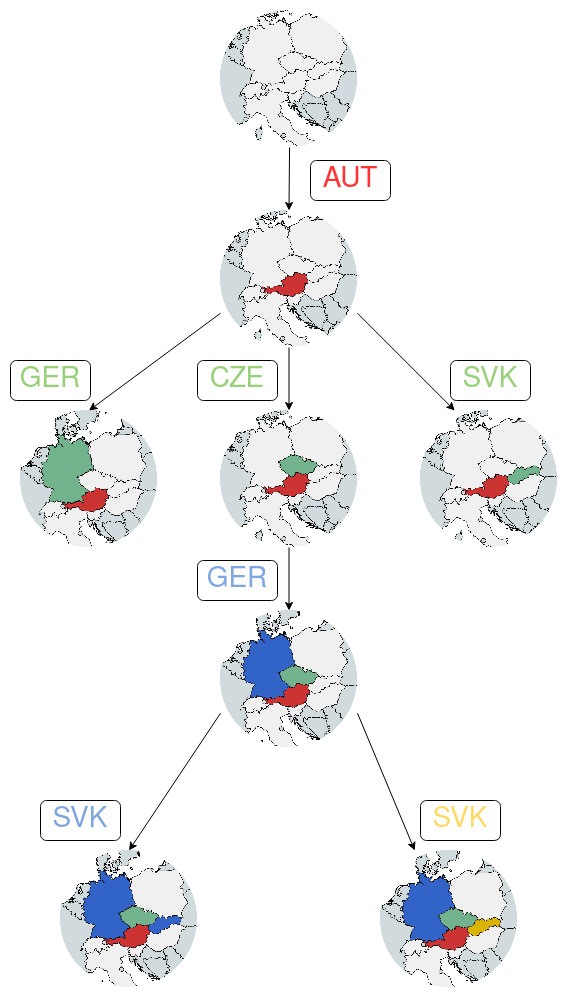

En el diagrama (árbol de búsqueda) podemos ver que cada nodo de la gráfica representa una coloración de regiones del mapa, es decir, un nodo está asociado a un estado del mapa. Sin embargo, una coloración del mapa pudo haber sido obtenida coloreando en distinto orden las regiones.

Veamos que nuestro nodo raíz representa el estado en que ninguna región ha sido coloreada.

### ¿Qué región colorear?

Si existiera una región que no tiene colores disponibles sabemos que estamos en un estado inconsistente y si existe una región con sólo un valor aceptable sabríamos que es necesario asignar ese valor (colorear). Con esto tratamos de decir que un primer criterio para elegir qué región colorear puede ser cuántos valores existen en el dominio de la variable asociada a la región.

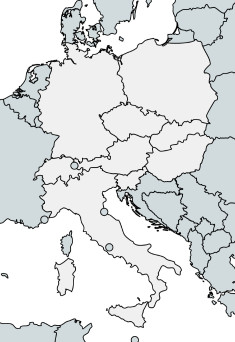

Inicialmente podemos colorear cualquier región (9 posibles) de cualquier color (4 disponibles). Entonces, la cantidad de nodos hijo para la raíz será de 36 nodos hijo. En el diagrama tomamos, ingeniosamente, el nodo hijo que muestra a *AUT* coloreado. Nótese que el color no es importante, pero se toma al primer elemento de la lista de colores.

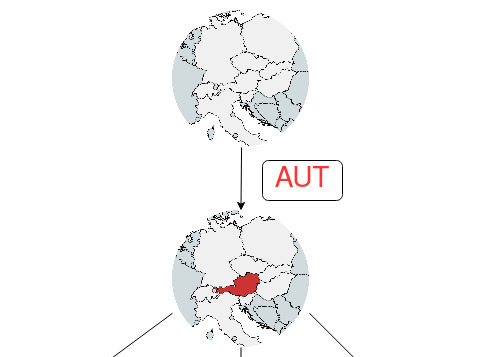

Las posibles acciones a tomar son: colorear a uno de los vecinos de *AUT* de un color distinto al rojo (sin pérdida de generalidad) ó colorear a un nodo que no es vecino de *AUT* y colorearlo con cualquiera de los colores. Esto nos da por resultado, que existan 25 nodos hijo.

**Pregunta:**

Si nuestra primer elección fuera colorear una región DISTINTA de *AUT*, ¿aumenta o disminuye la cantidad de acciones a tomar? Explique su respuesta.

La cantidad de nodos hijos podría aumentar, disminuir o mantenerse igual dependiendo de la región elegida. Podemos afirmar que la elección de la primera región a colorear tiene un impacto directo en la estructura del árbol de búsqueda y, por lo tanto, en la eficiencia de los algoritmos de búsqueda.

Con lo anterior, tratamos de desarrollar la intuición sobre el hecho de que: *una segunda decisión sobre cuál región es más conveniente colorear, estará dada por el número de regiones vecinas que se ven afectadas*. En nuestro caso partícular, es preferible colorear Austria debido a que **reduce el dominio de las variables asociadas a sus regiones vecinas**.

Para el caso de la segunda región a colorear, veremos que *GER*, *CZE*, *SVK*, *SUI*, *HUN*, *ITA* y *SLO* tienen tres valores en su dominio (*verde*, *azul* y *amarillo*) y bajo este criterio son "deseables" para colorear comparados con *POL*.

Dentro de este grupo de más deseables, *GER*, *CZE* y *SVK* son más deseables que *SUI*, *HUN*, *ITA* y *SLO* porque tienen una mayor cantidad de vecinos sin colorear.

Cómo último criterio para decidir tomaremos las siglas del nombre de la región en orden alfabético. Hacemos notar que esta decisión es arbitraria y no afecta la eficiencia del algortimo. Y dado que se ha utilizado solamente un color, podemos elegir (sin pérdida de generalidad) al color verde.

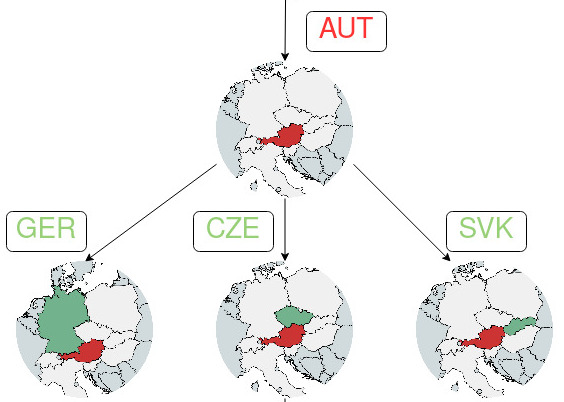

Esta misma situación sucederá al colorear la tercera región, teniendo por resultado **colorear *GER* de azul**.

### ¿Qué color debo usar?

Cuando decidamos colorear la cuarta región, tendremos bajo estos criterios que *SVK* es la siguiente región a colorear. Los colores disponibles para la región seleccionada serán *azul* y *amarillo*.

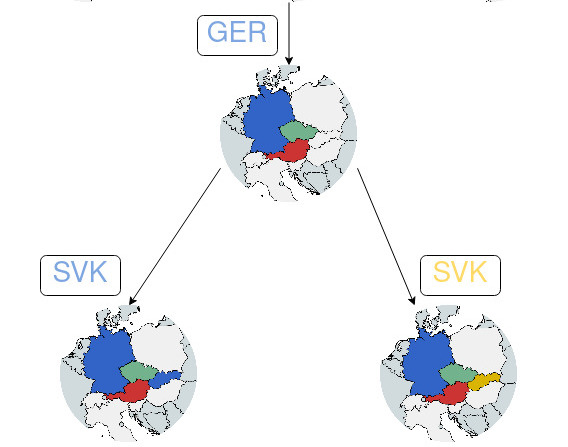

Si seleccionamos colorear *SVK* de azul, el dominio de *POL* NO se verá reducido como consecuencia mientras que el de Hungría si será disminuido. Mientras tanto, si decidimos colorear *SVK* de amarillo, tanto el dominio de *POL* y *HUN* se verán disminuidos. La heurística que usaremos para elegir el color será: **"seleccionar el color que restrinja menos el dominio de las variables y en caso de empate seleccionar por algún orden subjetivo, por ejemplo alfabeticamente".**

### Relación con la definición de Region

Como se indicó en la primera parte de este documento, la definición de la clase fue modificada para que el operador ***\_lt\_*** nos permita ordenar las regiones por deseabilidad. Se sugiere regresar a la definición de esta clase para verificar que esta definición sea adecuada.

### Nodo

Teniendo en cuenta lo anterior, notamos que podemos representar la información del conjunto de regiones y sus colores disponibles en una sola clase. Por ello definimos la clase **Node**.

In [ ]:
class Node:

    def __init__(self,actual_state):
        self.actual_state      = copy.deepcopy(actual_state)
        self.uncolored_regions = [ x.name for x in actual_state.values() if x.status == "No coloreado" ]
        self.level             = sum([ 1 for x in actual_state.values() if x.status == "Coloreado" ])


    # Método que nos permite ordenar por prioridad las regiones por colorear
    def region_priority(self):
        # Crear una lista de las regiones no coloreadas y ordenarla
        sorted_regions = sorted([ x for x in self.actual_state.values() if x.status == "No coloreado" ])
        # Devolver únicamente el nombre de las regiones
        return [ x.name for x in sorted_regions ]


    # Método que dada una región a colorear, nos permite saber cuál color utilizar
    def color_priority(self,region_name,graph):
        priority_list = []
        # Para cada color con el que se puede colorear:
        for color in self.actual_state[region_name].available_colors:
            # Calcular cuántos valores reducirá en el dominio
            color_tuple = (calculate_constraining_value(self.actual_state,region_name,color,graph),color)
            priority_list.append(color_tuple)
        # Ordenar los colores de acuerdo al que menos restrinja y como desempate usar orden alfabético.
        return [ color for value,color in sorted(priority_list) ]


    # Método para imprimir un nodo y saber cuáles regiones no se han coloreado
    def print(self):
        print( "Regiones sin colorear: {}".format(self.uncolored_regions) )
        print( "Nivel en árbol de búsqueda: {}".format(self.level) )

In [ ]:
# Ejemplo de sort de tuplas
valores_y_colores = [(2,'verde'),(1,'zafiro'),(2,'azul'),(1,'rojo')]
sorted(valores_y_colores)

[(1, 'rojo'), (1, 'zafiro'), (2, 'azul'), (2, 'verde')]

La siguiente función nos permite, una vez que hayamos seleccionado una región para colorear, conocer cuántos valores serán restringidos del dominio para cada color disponible en la región previamente seleccionada. Nuestra intención es restringir la menor cantidad.

In [ ]:
# Función que dado el estado actual, el nombre de una región y un color, así como la gráfica del mapa:
#    - Calcula para los vecinos de esa región, cuántos de ellos tienen al valor indicado entre sus opciones
#    - Devuelve el valor calculado
def calculate_constraining_value(actual_state,region_name,color,graph):

    constraining_value = 0

    for neighbour in graph[region_name]:

        if( color in actual_state[neighbour].available_colors ):
            constraining_value += 1

    return constraining_value

Esta es la función principal que nos ayudará a que la coloración del mapa se haga mediante una búsqueda. Nótese que una aproximación mediante una función "greedy" y las heurísticas planteadas nos permitirá resolver el problema. Sin embargo, la función está planteada para hacer uso de la estrategia de "backtracking" a pesar de no ser necesaria para la resolución del problema.

In [ ]:
# Función que automatiza la búsqueda para colorear el mapa,
#    dado el nodo inicial y la gráfica del mapa
def make_search(actual_node,graph):

    # Si ya no hay regiones por colorear, hemos terminado
    if( actual_node.uncolored_regions == [] ):

        # Crear un diccionario para devolver la respuesta
        map_coloring = {}

        for region in actual_node.actual_state.values():
            map_coloring[region.name] = list( region.available_colors )[0]

        return map_coloring

    # Si hay regiones por colorear, hacer lo sigiente:
    #  - Ordenar las regiones por prioridad e iterar sobre ellas.
    for coloring_region in actual_node.region_priority():

        #  - Para cada región, iterar sobre los colores disponibles
        for coloring_value in actual_node.color_priority(coloring_region,graph):

            # Crear una copia del estado actual para poder modificar los colores del mapa
            next_state = copy.deepcopy(actual_node.actual_state)

            # Verificar si la operación "colorear" pudo ser aplicada
            status = coloring(next_state,coloring_region,coloring_value,graph)

            if( status == "Imposible colorearlo así"):
                continue

            # En caso de que se haya podido aplicar la operación:
            #    - Crear un nodo hijo.
            #    - Comenzar la búsqueda desde el nodo hijo y esperar por la respuesta
            child_node = Node(next_state)
            status     = make_search(child_node,graph)

            # Si hay una respuesta (diccionario), devolverlo
            if( status != None ):
                return status

    return None

En la siguiente creamos el nodo raíz.

In [ ]:
root_node = Node(initial_state)
root_node.print()

Regiones sin colorear: ['GER', 'POL', 'CZE', 'SVK', 'SUI', 'AUT', 'HUN', 'ITA', 'SLO']
Nivel en árbol de búsqueda: 0


Una vez que se realiza la búsqueda, la coloración encontrada con las heurísticas planteadas es:

In [ ]:
make_search(root_node,graph)

{'GER': 'Red',
 'POL': 'Blue',
 'CZE': 'Green',
 'SVK': 'Red',
 'SUI': 'Yellow',
 'AUT': 'Blue',
 'HUN': 'Green',
 'ITA': 'Green',
 'SLO': 'Red'}